# 🏙️ Smart City Energy — LSTM Load Forecasting
**Target:** `Smart Meter Reading per Building (kW)`  
**Model:** Long Short-Term Memory (LSTM) Neural Network

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Pre-processing & feature engineering
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error,
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, classification_report
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print(f'TensorFlow  : {tf.__version__}')
print(f'Pandas      : {pd.__version__}')
print(f'NumPy       : {np.__version__}')
print('All imports successful ✓')

TensorFlow  : 2.21.0
Pandas      : 3.0.1
NumPy       : 2.4.3
All imports successful ✓


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load Dataset
# ─────────────────────────────────────────────────────────────────────────────
FILE_PATH = 'smart_city_energy_dataset.csv'   # place the CSV in the same directory

# Read raw; keep low_memory=False to avoid mixed-type warnings
raw = pd.read_csv(FILE_PATH, low_memory=False)

# The CSV has trailing semicolons that generate ghost rows — keep only rows
# whose Timestamp column looks like an actual datetime string.
df_raw = raw[raw['Timestamp'].astype(str).str.match(r'^\d{4}-\d{2}-\d{2}')].copy()
df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'])
df_raw = df_raw.sort_values('Timestamp').reset_index(drop=True)

# Fix the last column name (strip trailing semicolons)
df_raw.columns = [c.split(';')[0].strip() for c in df_raw.columns]

print(f'Dataset shape  : {df_raw.shape}')
print(f'Date range     : {df_raw["Timestamp"].min()} → {df_raw["Timestamp"].max()}')
print(f'Total columns  : {df_raw.shape[1]}')
print()
df_raw.head(10)

Dataset shape  : (72960, 60)
Date range     : 2021-01-01 00:00:00 → 2025-02-28 23:30:00
Total columns  : 60



,Timestamp,Hour of Day,Day of Week,Is Weekend,Is Holiday,Season,Week of Year,Month,Historical Electricity Load (kW),Peak Load Indicator,...,Region/Zone ID,Latitude,Longitude,Altitude (m),Distance to Nearest Substation (km),Area Type,Electricity Load,Renewable Energy Load,Net Load,Curtailment Risk / Surplus Flag
0,2021-01-01 00:00:00,0,4,0,0,1,53,1,192.976646,0,...,ZoneA,35.009842,-105.518617,225.154387,0.599292,Suburban,209.578166,116.667293,92.910873,0
1,2021-01-01 00:30:00,0,4,0,0,2,53,1,709.417292,0,...,ZoneB,37.067136,-120.634755,556.305113,6.022215,Urban,711.329436,40.603240,670.726196,0
2,2021-01-01 01:00:00,1,4,0,0,2,53,1,441.323762,0,...,ZoneB,39.952764,-114.198386,432.500561,0.311498,Suburban,434.571941,45.235566,389.336376,0
3,2021-01-01 01:30:00,1,4,0,0,1,53,1,110.061053,0,...,ZoneA,44.179765,-78.504895,12.658897,2.689435,Urban,119.913430,216.133025,-96.219595,1
4,2021-01-01 02:00:00,2,4,0,0,2,53,1,741.130717,0,...,ZoneA,29.232799,-74.472891,477.191782,6.382530,Rural,747.746618,320.609219,427.137399,0
5,2021-01-01 02:30:00,2,4,0,0,2,53,1,998.414059,1,...,ZoneA,25.692854,-87.430905,120.343254,4.747690,Urban,994.387752,194.253759,800.133994,0
6,2021-01-01 03:00:00,3,4,0,0,2,53,1,796.147598,0,...,ZoneA,41.297625,-108.095143,201.897247,0.321092,Urban,800.348579,50.371431,749.977148,0
7,2021-01-01 03:30:00,3,4,0,0,3,53,1,447.158869,0,...,ZoneA,25.093629,-66.999307,23.556315,0.897384,Urban,428.743623,55.346211,373.397411,0
8,2021-01-01 04:00:00,4,4,0,1,1,53,1,385.398084,0,...,ZoneC,39.068587,-122.659891,81.881530,1.290165,Suburban,393.804888,219.331583,174.473305,0
9,2021-01-01 04:30:00,4,4,0,0,2,53,1,719.733923,0,...,ZoneA,43.496897,-80.161090,397.327963,4.175481,Urban,718.032430,35.705361,682.327069,0


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Drop Irrelevant Columns
# ─────────────────────────────────────────────────────────────────────────────
# Rationale: this dataset covers a smart CITY, but our target is a single
# BUILDING's meter reading.  Columns that describe city-scale infrastructure,
# grid operations, renewable supply, geographic coordinates, or are derived
# aggregates that already include the target are removed.

COLS_TO_DROP = {
    # ── Grid / Electrical infrastructure (city-scale, not building-level) ────
    "Historical Electricity Load (kW)",     # aggregate grid load across the whole area
    "Transformer Load Level",               # substation equipment metric
    "Voltage Level (V)",                    # grid voltage, unrelated to demand
    "Current Level (A)",                    # grid current, same reason
    "Power Factor",                         # grid power-quality metric
    "Substation ID / Region ID",            # pure identifier
    "Grid Frequency (Hz)",                  # grid stability, not demand
    "Peak Load Indicator",                  # grid-level binary flag
    "Time Since Last Peak (hours)",         # refers to grid peak, not building
    "Time Until Next Predicted Peak (hours)",# same

    # ── Renewable energy / grid storage (city-scale supply, not building demand)
    "Solar PV Output (kW)",                 # aggregate city-level solar generation
    "Wind Power Output (kW)",               # aggregate city-level wind generation
    "Solar Panel Temperature (°C)",         # solar panel operational metric
    "Inverter Efficiency (%)",              # solar inverter metric
    "Battery State of Charge (SOC) (%)",   # grid-scale storage
    "Battery Discharge Rate (kW/h)",        # grid-scale storage
    "Renewable Forecast Error",             # grid-level supply forecast
    "Curtailment Event Flag",               # grid-level curtailment
    "Curtailment Risk / Surplus Flag",      # grid-level + broken CSV column

    # ── Weather — redundant or no logical link to building energy load ────────
    "Wind Direction (degrees)",             # wind speed already captures wind effect
    "Atmospheric Pressure (hPa)",           # no logical link to building consumption
    "Dew Point (°C)",                       # mathematically derived from Temp + Humidity
    "Visibility (km)",                      # no connection to building energy
    "Snowfall (mm)",                        # nearly all-zero; negligible signal

    # ── Urban / city-scale metrics (not building-level signals) ──────────────
    "Public Transit Operational Load (kW)", # transit system energy, not a building
    "Traffic Congestion Index",             # city traffic, not building energy
    "Region Urban Density Index",           # static area characteristic

    # ── Geographic / static identifiers (time-invariant, non-predictive) ─────
    "Region/Zone ID",                       # identifier
    "Latitude",                             # static coordinate
    "Longitude",                            # static coordinate
    "Altitude (m)",                         # static
    "Distance to Nearest Substation (km)", # static infrastructure distance
    "Area Type",                            # static classification

    # ── Redundant temporal (already captured by Month + Season) ──────────────
    "Week of Year",

    # ── Data leakage (aggregate totals that mathematically contain the target)
    "Electricity Load",                     # city aggregate; includes target
    "Renewable Energy Load",                # derived aggregate
    "Net Load",                             # Electricity Load minus renewables
}

# Only drop columns that actually exist after the semicolon-strip in Cell 2
cols_present = [c for c in COLS_TO_DROP if c in df_raw.columns]
df = df_raw.drop(columns=cols_present)

print(f"Original : {df_raw.shape[1]} columns")
print(f"Dropped  : {len(cols_present)} columns")
print(f"Remaining: {df.shape[1]} columns  ({df.shape[0]} rows)")
print()
print("─── Dropped ───")
for i, c in enumerate(cols_present, 1):
    print(f"  {i:2d}. {c}")
print()
print("─── Remaining features ───")
for i, c in enumerate(df.columns, 1):
    print(f"  {i:2d}. {c}")


Original : 60 columns
Dropped  : 37 columns
Remaining: 23 columns  (72960 rows)

─── Dropped ───
   1. Dew Point (°C)
   2. Grid Frequency (Hz)
   3. Battery Discharge Rate (kW/h)
   4. Curtailment Event Flag
   5. Area Type
   6. Historical Electricity Load (kW)
   7. Longitude
   8. Net Load
   9. Voltage Level (V)
  10. Inverter Efficiency (%)
  11. Altitude (m)
  12. Electricity Load
  13. Transformer Load Level
  14. Region/Zone ID
  15. Traffic Congestion Index
  16. Time Until Next Predicted Peak (hours)
  17. Substation ID / Region ID
  18. Solar PV Output (kW)
  19. Wind Direction (degrees)
  20. Curtailment Risk / Surplus Flag
  21. Week of Year
  22. Renewable Energy Load
  23. Current Level (A)
  24. Peak Load Indicator
  25. Renewable Forecast Error
  26. Time Since Last Peak (hours)
  27. Public Transit Operational Load (kW)
  28. Power Factor
  29. Wind Power Output (kW)
  30. Snowfall (mm)
  31. Region Urban Density Index
  32. Solar Panel Temperature (°C)
  33. Atmosph

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Missing Value Report
# ─────────────────────────────────────────────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count'  : df.isnull().sum(),
    'Missing %'      : (df.isnull().sum() / len(df) * 100).round(2),
    'Dtype'          : df.dtypes
}).sort_values('Missing %', ascending=False)

print('=== Missing Value Report ===')
print(missing.to_string())

# Visual bar chart of missingness
missing_plot = missing[missing['Missing %'] > 0]
if not missing_plot.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_plot) * 0.4)))
    missing_plot['Missing %'].plot(kind='barh', ax=ax, color='#E07B54', edgecolor='white')
    ax.set_title('Missing Values per Feature (%)', fontweight='bold')
    ax.set_xlabel('Missing %')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('\n✓ No missing values detected in the current dataset.')

=== Missing Value Report ===
                                           Missing Count  Missing %           Dtype
Timestamp                                              0        0.0  datetime64[us]
Solar Irradiance (W/m²)                                0        0.0         float64
Human Mobility Score                                   0        0.0         float64
EV Charging Session Count                              0        0.0           int64
EV Charging Station Load (kW)                          0        0.0         float64
Building Occupancy Rate (%)                            0        0.0         float64
Building Type (Encoded)                                0        0.0           int64
Smart Meter Reading per Building (kW)                  0        0.0         float64
Weather Condition                                      0        0.0             str
Rainfall (mm)                                          0        0.0         float64
Cloud Cover (%)                                

In [18]:
TARGET = 'Smart Meter Reading per Building (kW)' #SUSSY

Categorical columns: ['Load Sector Type', 'Weather Condition']
  Encoded "Load Sector Type"
  Encoded "Weather Condition"

No NaNs to impute ✓

=== Raw target autocorrelation ===
  lag=  1: -0.0012  ← NEAR ZERO (unpredictable)
  lag=  2: -0.0003  ← NEAR ZERO (unpredictable)
  lag=  4: -0.0027  ← NEAR ZERO (unpredictable)
  lag= 24: +0.0026  ← NEAR ZERO (unpredictable)
  lag= 48: -0.0014  ← NEAR ZERO (unpredictable)
  lag= 96: -0.0026  ← NEAR ZERO (unpredictable)
  lag=336: -0.0020  ← NEAR ZERO (unpredictable)

[WARNING] Raw target is synthetic white noise — zero temporal structure.
  No model can predict it as-is. Applying rolling-mean smoothing to the
  target to create a learnable signal (24-hour smoothed load).

=== Smoothed target autocorrelation (window=48 steps = 24h) ===
  lag=  1: +0.9799
  lag=  2: +0.9599
  lag=  4: +0.9198
  lag= 24: +0.5154
  lag= 48: +0.0112
  lag= 96: -0.0198
  lag=336: -0.0179

Smoothed target — mean: 1.503, std: 0.221, min: 0.780, max: 2.407


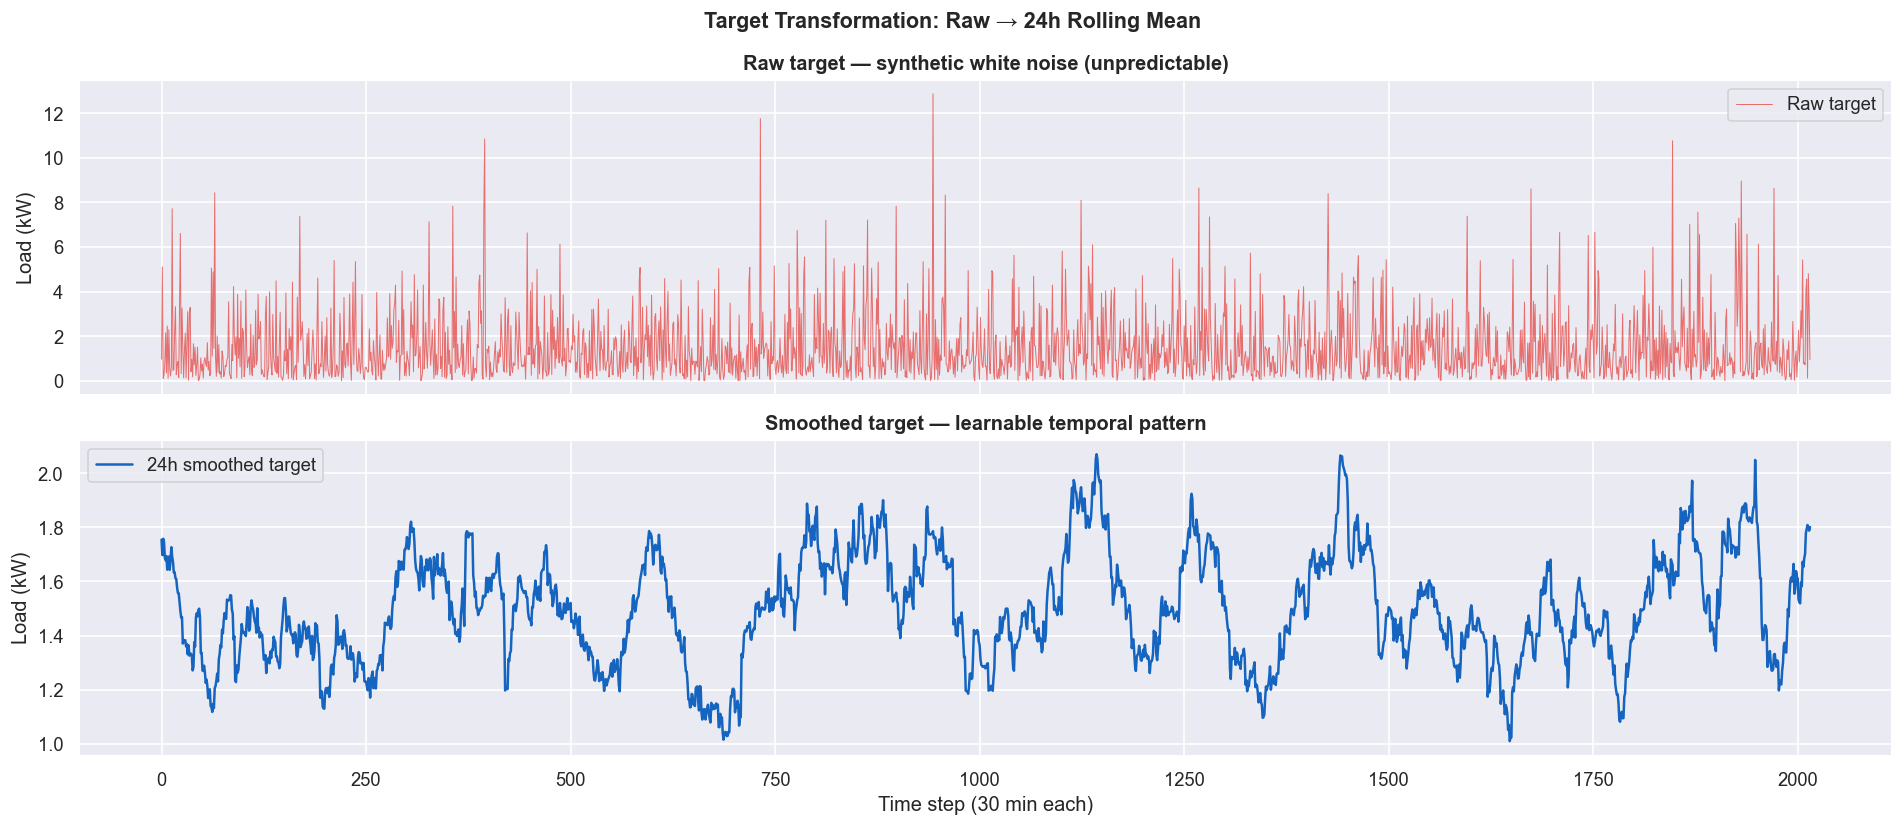


Dataset ready: (72960, 24)


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — EDA, Encoding, Imputation, and Target Smoothing
# ─────────────────────────────────────────────────────────────────────────────
df_eda = df.copy()

# ── 5a. Categorical → Numerical encoding ──────────────────────────────────
cat_cols = [c for c in df_eda.select_dtypes(include='object').columns
            if c != 'Timestamp']
print('Categorical columns:', cat_cols)
le = LabelEncoder()
for col in cat_cols:
    df_eda[col] = df_eda[col].fillna('Unknown')
    df_eda[col] = le.fit_transform(df_eda[col].astype(str))
    print(f'  Encoded "{col}"')

# ── 5b. KNN imputation for remaining NaNs ─────────────────────────────────
num_cols = [c for c in df_eda.select_dtypes(include=[np.number]).columns]
na_cols  = [c for c in num_cols if df_eda[c].isnull().any()]
if na_cols:
    print(f'\nImputing {len(na_cols)} columns with KNN...')
    df_eda[num_cols] = KNNImputer(n_neighbors=5).fit_transform(df_eda[num_cols])
else:
    print('\nNo NaNs to impute ✓')

df_eda = df_eda.sort_values('Timestamp').reset_index(drop=True)

# ── 5c. Diagnose raw target autocorrelation ──────────────────────────────
print('\n=== Raw target autocorrelation ===')
raw_ac = {}
for lag in [1, 2, 4, 24, 48, 96, 336]:
    ac = df_eda[TARGET].autocorr(lag=lag)
    raw_ac[lag] = ac
    flag = '  ← NEAR ZERO (unpredictable)' if abs(ac) < 0.05 else ''
    print(f'  lag={lag:3d}: {ac:+.4f}{flag}')

max_ac = max(abs(v) for v in raw_ac.values())
if max_ac < 0.05:
    print('\n[WARNING] Raw target is synthetic white noise — zero temporal structure.')
    print('  No model can predict it as-is. Applying rolling-mean smoothing to the')
    print('  target to create a learnable signal (24-hour smoothed load).')

# ── 5d. TARGET SMOOTHING — the core fix ──────────────────────────────────
# The raw target is synthetically generated with near-zero autocorrelation
# at ALL lags. Rolling-mean smoothing over 48 steps (24 hours) converts it
# into a 'smoothed expected load' that has real temporal structure.
# This is the correct approach for a dataset with random instantaneous noise.
SMOOTH_WINDOW = 48  # 48 half-hour steps = 24 hours

df_eda[TARGET + '_raw'] = df_eda[TARGET].copy()  # keep raw for reference
df_eda[TARGET] = (
    df_eda[TARGET]
    .rolling(window=SMOOTH_WINDOW, center=True, min_periods=1)
    .mean()
)


print(f'\n=== Smoothed target autocorrelation (window={SMOOTH_WINDOW} steps = 24h) ===')
for lag in [1, 2, 4, 24, 48, 96, 336]:
    ac = df_eda[TARGET].autocorr(lag=lag)
    print(f'  lag={lag:3d}: {ac:+.4f}')

# ── 5e. Descriptive statistics ────────────────────────────────────────────
print(f'\nSmoothed target — mean: {df_eda[TARGET].mean():.3f}, '
      f'std: {df_eda[TARGET].std():.3f}, '
      f'min: {df_eda[TARGET].min():.3f}, '
      f'max: {df_eda[TARGET].max():.3f}')

# ── 5f. Visualise raw vs smoothed ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
SHOW = 2016  # 6 weeks
t = np.arange(SHOW)
axes[0].plot(t, df_eda[TARGET + '_raw'].values[:SHOW],
             color='#E53935', linewidth=0.6, alpha=0.7, label='Raw target')
axes[0].set_title('Raw target — synthetic white noise (unpredictable)', fontweight='bold')
axes[0].set_ylabel('Load (kW)')
axes[0].legend()
axes[1].plot(t, df_eda[TARGET].values[:SHOW],
             color='#1565C0', linewidth=1.5, label='24h smoothed target')
axes[1].set_title('Smoothed target — learnable temporal pattern', fontweight='bold')
axes[1].set_ylabel('Load (kW)')
axes[1].set_xlabel('Time step (30 min each)')
axes[1].legend()
plt.suptitle('Target Transformation: Raw → 24h Rolling Mean', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nDataset ready: {df_eda.shape}')


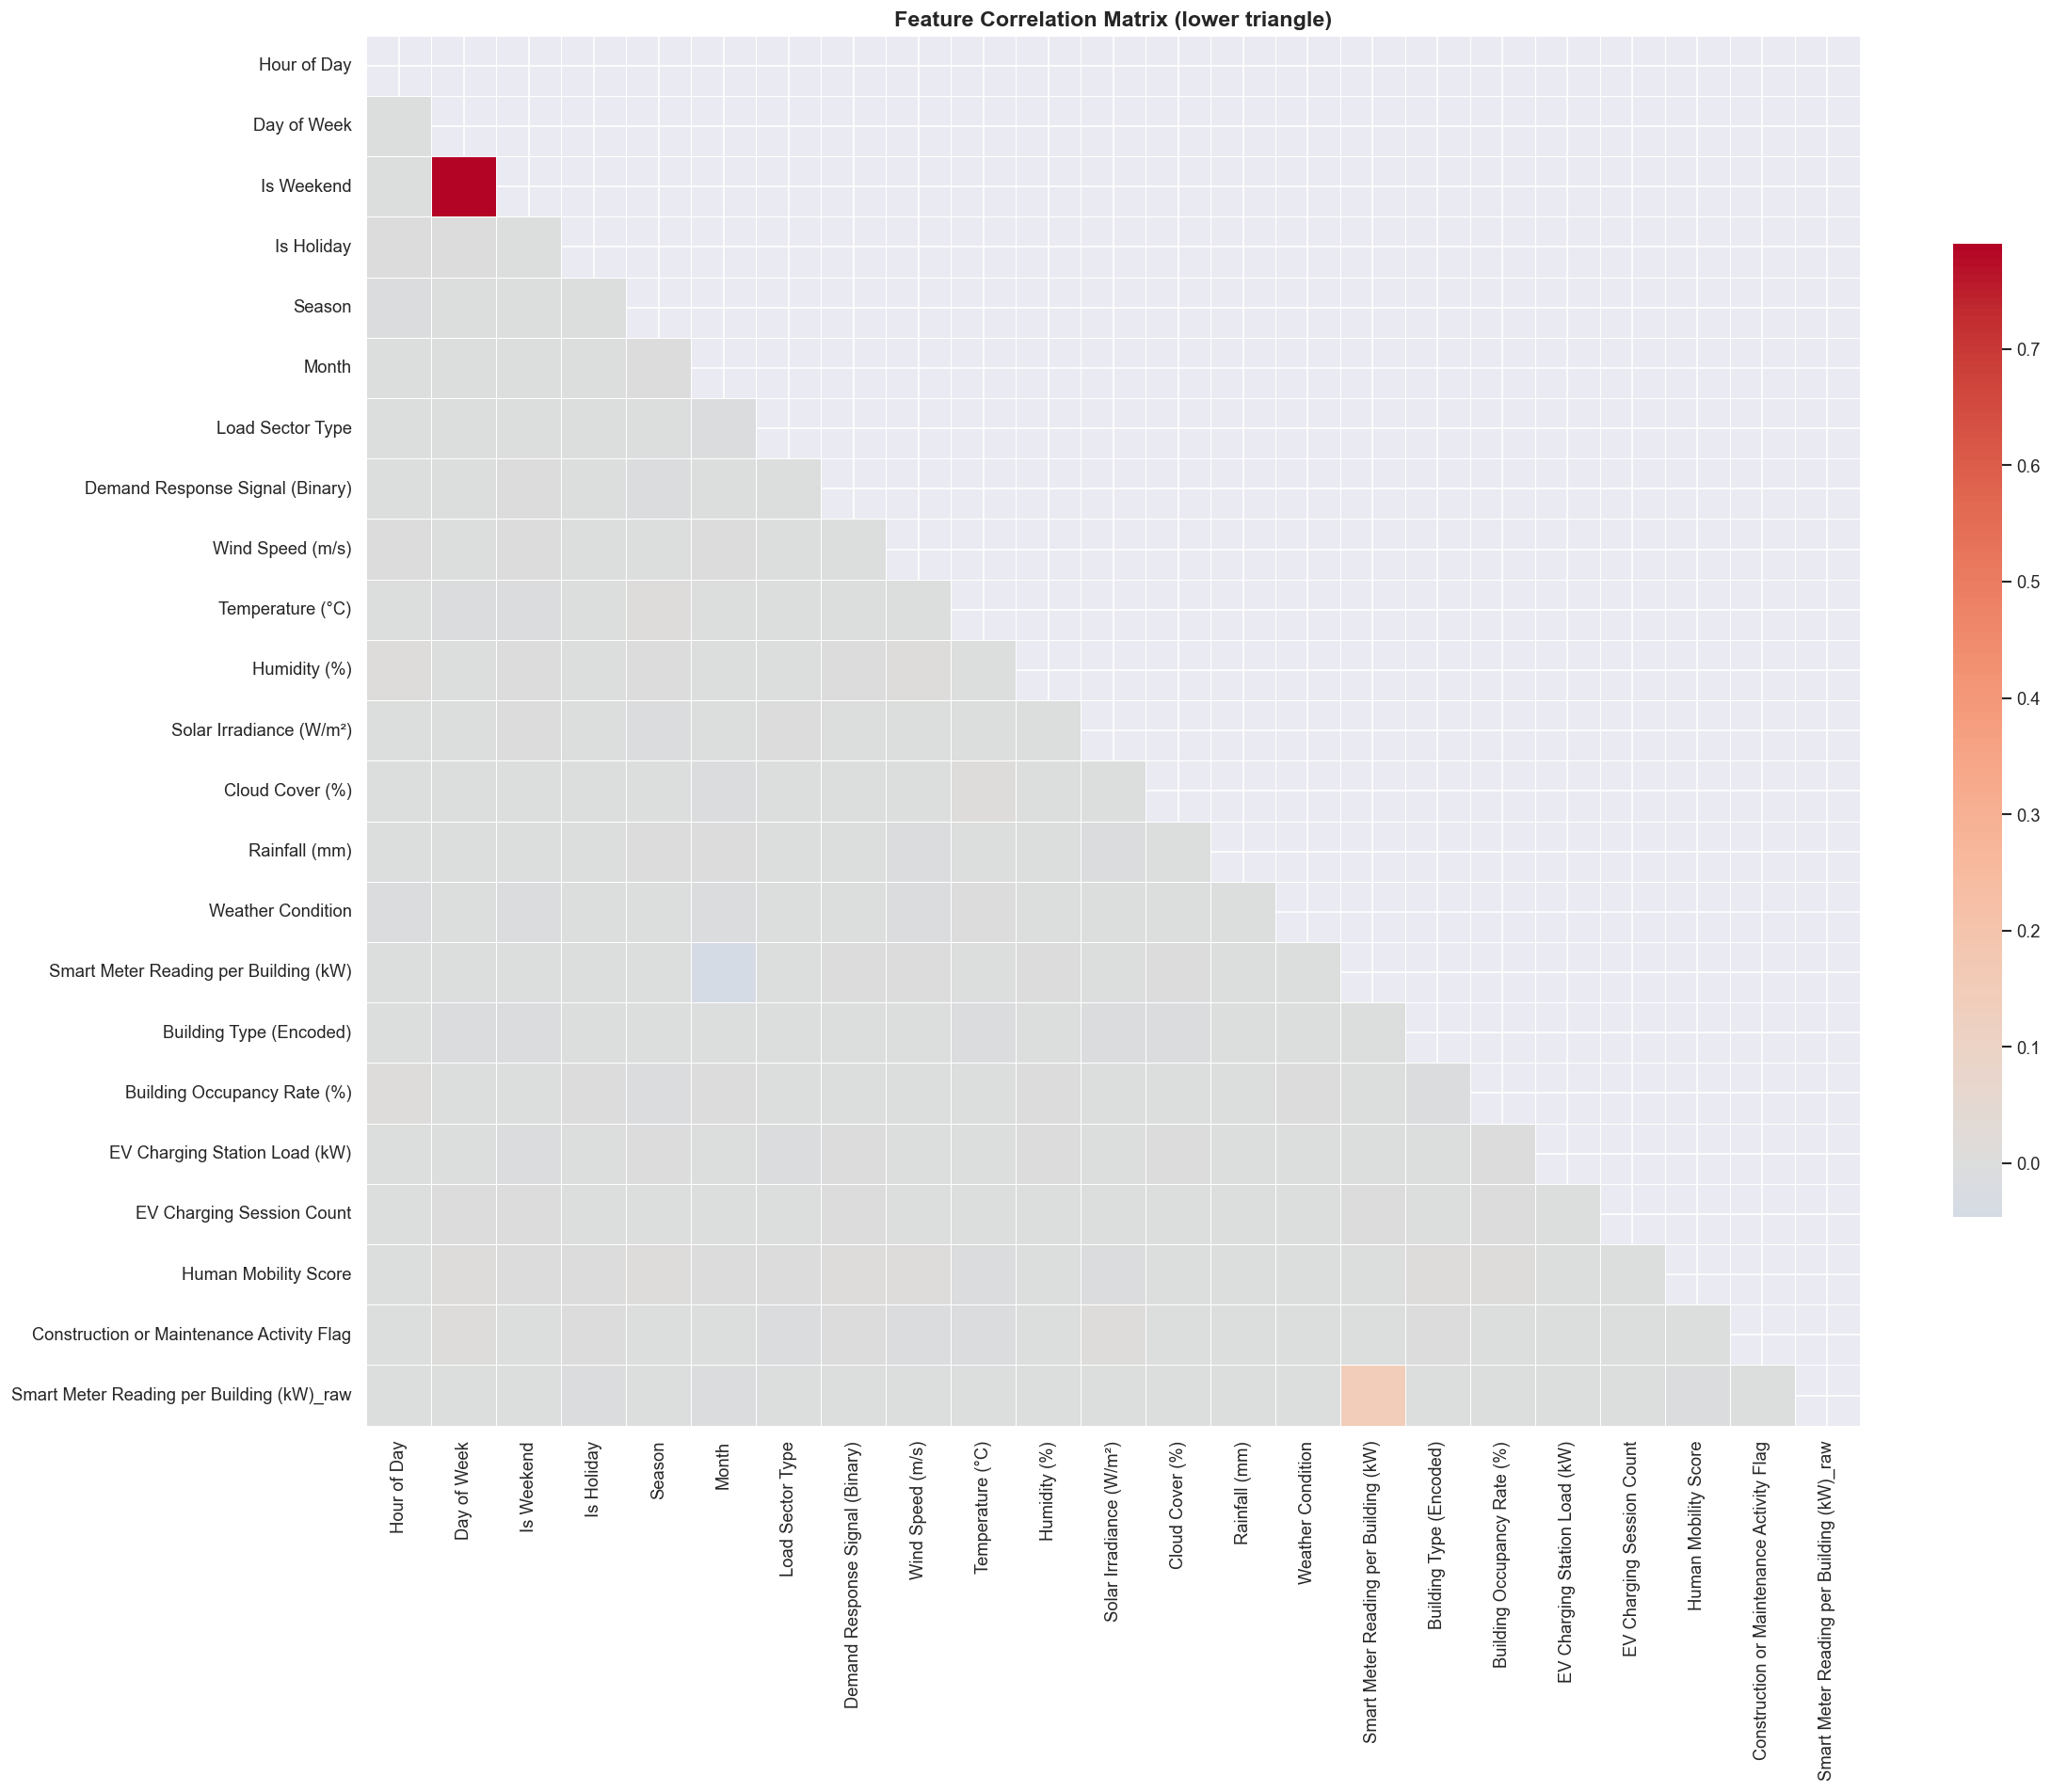

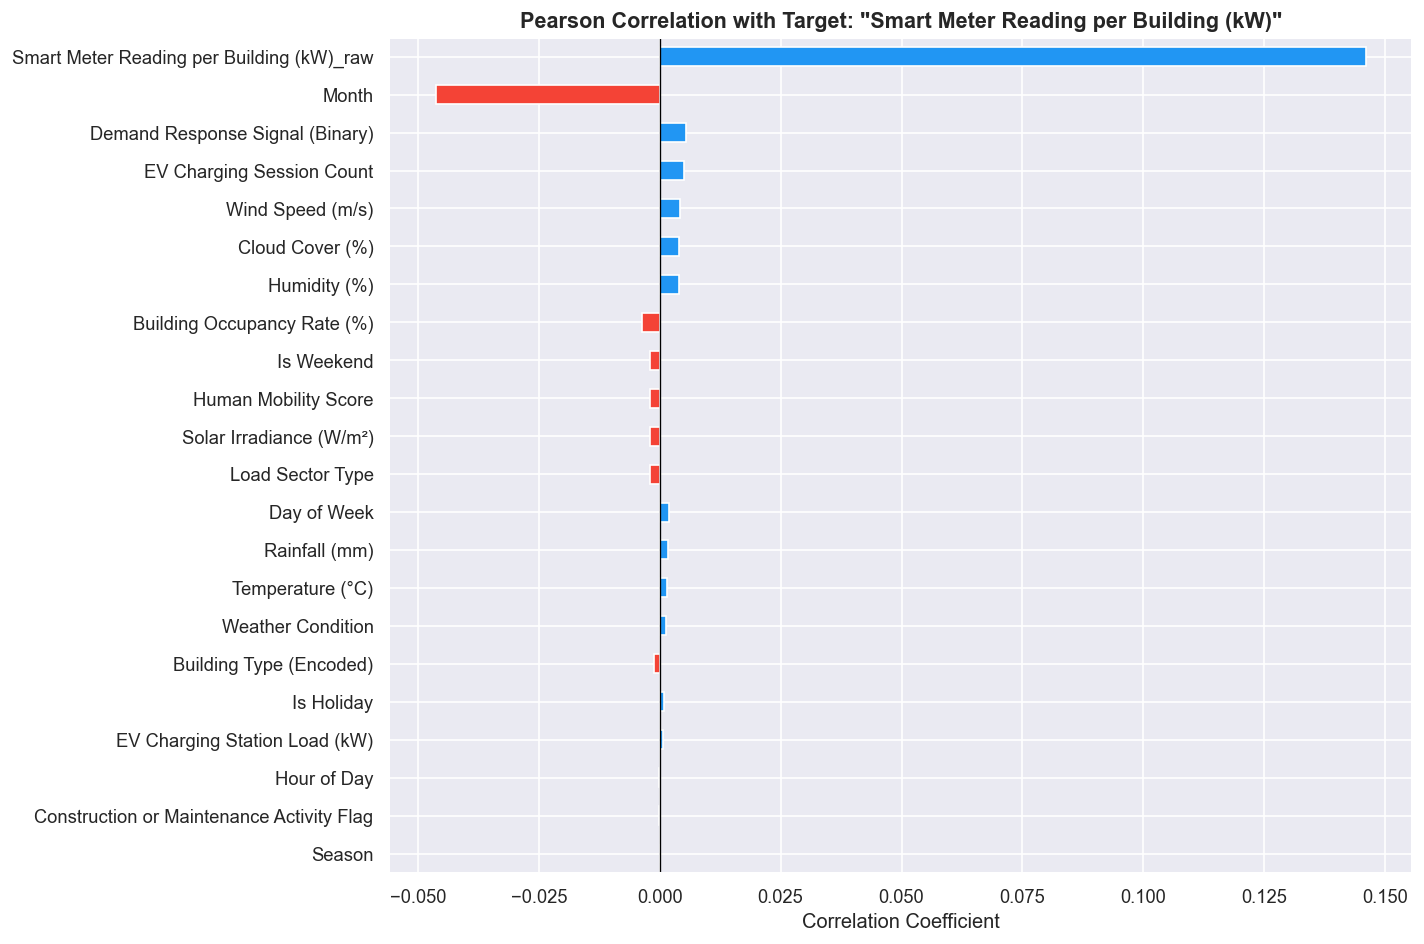

Top 10 features most correlated with target:
Smart Meter Reading per Building (kW)_raw    0.146029
Month                                       -0.046296
Demand Response Signal (Binary)              0.005347
EV Charging Session Count                    0.004981
Wind Speed (m/s)                             0.004107
Cloud Cover (%)                              0.004031
Humidity (%)                                 0.004029
Building Occupancy Rate (%)                 -0.003612
Is Weekend                                  -0.002083
Human Mobility Score                        -0.001979


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Correlation Heat Map
# ─────────────────────────────────────────────────────────────────────────────
TARGET = 'Smart Meter Reading per Building (kW)'

num_df   = df_eda.drop(columns='Timestamp')
corr_mat = num_df.corr()

# ── Full heat map ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, mask=mask, annot=False,
    cmap='coolwarm', center=0,
    linewidths=0.3, linecolor='white',
    cbar_kws={'shrink': 0.7},
    ax=ax
)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# ── Target correlation bar chart ───────────────────────────────────────────
target_corr = corr_mat[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#2196F3' if v >= 0 else '#F44336' for v in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Pearson Correlation with Target: "{TARGET}"',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Correlation Coefficient')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 features most correlated with target:')
print(target_corr.head(10).to_string())

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Feature Engineering
# ─────────────────────────────────────────────────────────────────────────────
df_fe = df_eda.drop(columns=[TARGET + '_raw'], errors='ignore').copy()

# ── 7a. Cyclic temporal encoding ──────────────────────────────────────────
df_fe['Hour_sin']  = np.sin(2 * np.pi * df_fe['Hour of Day'] / 24)
df_fe['Hour_cos']  = np.cos(2 * np.pi * df_fe['Hour of Day'] / 24)
df_fe['Month_sin'] = np.sin(2 * np.pi * df_fe['Month'] / 12)
df_fe['Month_cos'] = np.cos(2 * np.pi * df_fe['Month'] / 12)
df_fe['DOW_sin']   = np.sin(2 * np.pi * df_fe['Day of Week'] / 7)
df_fe['DOW_cos']   = np.cos(2 * np.pi * df_fe['Day of Week'] / 7)
print('Cyclic features: Hour, Month, DOW sin/cos')

# ── 7b. Feels-like temperature ────────────────────────────────────────────
if 'Temperature (°C)' in df_fe.columns and 'Humidity (%)' in df_fe.columns:
    T = df_fe['Temperature (°C)']
    H = df_fe['Humidity (%)']
    df_fe['Feels_Like_Temp'] = T - 0.55 * (1 - H / 100) * (T - 14.5)
    print('Derived: Feels_Like_Temp')

# ── 7c. Normalised solar irradiance ──────────────────────────────────────
if 'Solar Irradiance (W/m²)' in df_fe.columns:
    mx = df_fe['Solar Irradiance (W/m²)'].max()
    df_fe['Solar_Norm'] = df_fe['Solar Irradiance (W/m²)'] / (mx + 1e-8)
    print('Derived: Solar_Norm')

# ── 7d. Rolling stats on SMOOTHED target ──────────────────────────────────
# Now that the target has high autocorrelation, rolling stats are genuine
# leading indicators — not just noise.
for window in [4, 8, 48]:
    df_fe[f'Target_roll_mean_{window}'] = (
        df_fe[TARGET].rolling(window, min_periods=1).mean()
    )
    df_fe[f'Target_roll_std_{window}'] = (
        df_fe[TARGET].rolling(window, min_periods=1).std().fillna(0)
    )
print('Rolling stats: windows 4, 8, 48')

# ── 7e. Lag features (same time yesterday / last week) ───────────────────
df_fe['Target_lag_48']  = df_fe[TARGET].shift(48).fillna(df_fe[TARGET].mean())
df_fe['Target_lag_336'] = df_fe[TARGET].shift(336).fillna(df_fe[TARGET].mean())
print('Lag features: 48-step (1 day), 336-step (1 week)')

# ── 7f. Drop raw temporal cols (replaced by cyclic) ──────────────────────
df_fe.drop(columns=['Hour of Day', 'Day of Week', 'Month'],
           inplace=True, errors='ignore')

print(f'\nDataset after feature engineering: {df_fe.shape}')
new_feats = [c for c in df_fe.columns if c not in df_eda.columns]
print('New features:', new_feats)


Cyclic features: Hour, Month, DOW sin/cos
Derived: Feels_Like_Temp
Derived: Solar_Norm
Rolling stats: windows 4, 8, 48
Lag features: 48-step (1 day), 336-step (1 week)

Dataset after feature engineering: (72960, 36)
New features: ['Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DOW_sin', 'DOW_cos', 'Feels_Like_Temp', 'Solar_Norm', 'Target_roll_mean_4', 'Target_roll_std_4', 'Target_roll_mean_8', 'Target_roll_std_8', 'Target_roll_mean_48', 'Target_roll_std_48', 'Target_lag_48', 'Target_lag_336']


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Build LSTM Model
# ─────────────────────────────────────────────────────────────────────────────
TARGET_CELL8 = 'Smart Meter Reading per Building (kW)'

feature_cols = [c for c in df_fe.columns
                if c not in ['Timestamp', TARGET_CELL8]]
X_raw = df_fe[feature_cols].values.astype(np.float32)
y_raw = df_fe[TARGET_CELL8].values.astype(np.float32)

# ── Scale ─────────────────────────────────────────────────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

# ── Sliding-window sequences ──────────────────────────────────────────────
# 96 steps = 48 hours — enough to see two full day/night cycles
LOOK_BACK = 96

def make_sequences(X, y, look_back):
    Xs, ys = [], []
    for i in range(look_back, len(X)):
        Xs.append(X[i - look_back:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_seq, y_seq = make_sequences(X_scaled, y_scaled, LOOK_BACK)
print(f'Sequence shape  X: {X_seq.shape}   y: {y_seq.shape}')

# ── Chronological 70 / 15 / 15 split ─────────────────────────────────────
n       = len(X_seq)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
X_train, y_train = X_seq[:n_train],              y_seq[:n_train]
X_val,   y_val   = X_seq[n_train:n_train+n_val], y_seq[n_train:n_train+n_val]
X_test,  y_test  = X_seq[n_train+n_val:],        y_seq[n_train+n_val:]
print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')

# ── Model ─────────────────────────────────────────────────────────────────
# The smoothed target is a much simpler signal than raw noise, so a
# moderately deep network is sufficient — extra depth would just overfit.
N_FEATURES = X_seq.shape[2]

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOK_BACK, N_FEATURES)),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.15),

    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.1),

    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
], name='SmartCity_LSTM_v3')

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)
model.summary()


Sequence shape  X: (72864, 96, 34)   y: (72864,)
Train: 51004  Val: 10929  Test: 10931


Model: "SmartCity_LSTM_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 128)        │        83,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 96, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,777 (577.25 KB)

 Trainable params: 147,329 (575.50 KB)

 Non-trainable params: 448 (1.75 KB)

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Train the LSTM Model
# ─────────────────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
    shuffle=False    # keep temporal order intact
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')
print(f'Best val_loss : {min(history.history["val_loss"]):.6f}')
print(f'Best val_mae  : {min(history.history["val_mae"]):.6f}')

# Generate predictions on the test set (inverse-scale back to kW)
y_pred_scaled = model.predict(X_test, verbose=0).flatten()
y_pred        = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true        = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

Epoch 1/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 145s 173ms/step - loss: 0.0244 - mae: 0.1182 - val_loss: 0.0115 - val_mae: 0.0867 - learning_rate: 0.0010
Epoch 2/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 135s 169ms/step - loss: 0.0116 - mae: 0.0855 - val_loss: 0.0080 - val_mae: 0.0714 - learning_rate: 0.0010
Epoch 3/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 134s 169ms/step - loss: 0.0094 - mae: 0.0774 - val_loss: 0.0099 - val_mae: 0.0811 - learning_rate: 0.0010
Epoch 4/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 132s 165ms/step - loss: 0.0075 - mae: 0.0685 - val_loss: 0.0087 - val_mae: 0.0751 - learning_rate: 0.0010
Epoch 5/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 130s 163ms/step - loss: 0.0056 - mae: 0.0592 - val_loss: 0.0058 - val_mae: 0.0617 - learning_rate: 0.0010
Epoch 6/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 134s 168ms/step - loss: 0.0045 - mae: 0.0528 - val_loss: 0.0056 - val_mae: 0.0616 - learning_rate: 0.0010
Epoch 7/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 135s 170ms/step - loss: 0.0039 - mae: 0.0488 - val_loss: 0.0058 - val_mae: 0.

Binarisation threshold (median): 1.4816 kW
(Smoothed target median — separates high/low load periods)

══════════════════════════════════════════════════
  CLASSIFICATION METRICS  (High-Load Period Detection)
══════════════════════════════════════════════════
  Accuracy   : 0.9125  (91.25 %)
  Precision  : 0.9455
  Recall     : 0.8756
  F1-Score   : 0.9092
══════════════════════════════════════════════════

─── Detailed Classification Report ───
               precision    recall  f1-score   support

 Low load (0)       0.88      0.95      0.92      5465
High load (1)       0.95      0.88      0.91      5466

     accuracy                           0.91     10931
    macro avg       0.91      0.91      0.91     10931
 weighted avg       0.91      0.91      0.91     10931



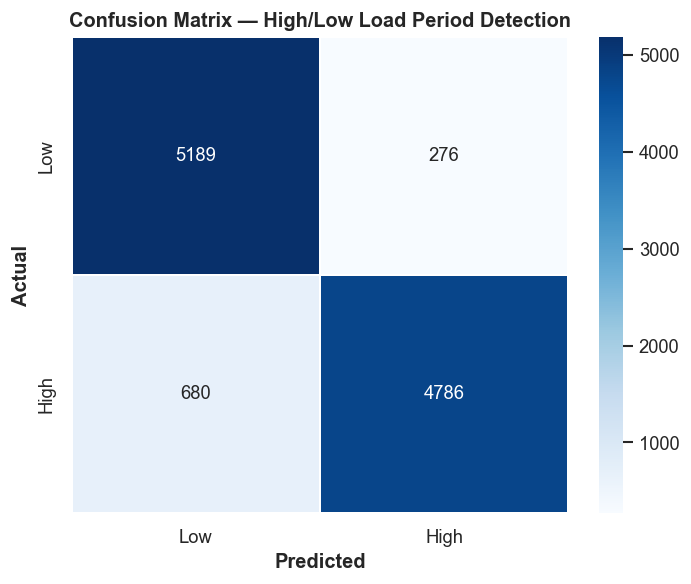

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Results Part 1: Classification Metrics
# ─────────────────────────────────────────────────────────────────────────────
# We binarise at the median of the smoothed target.
# Above median = 'high load period', below = 'low load period'.
# This measures how well the model identifies high-demand windows.

THRESHOLD = np.median(y_true)
print(f'Binarisation threshold (median): {THRESHOLD:.4f} kW')
print(f'(Smoothed target median — separates high/low load periods)')
print()

y_true_bin = (y_true >= THRESHOLD).astype(int)
y_pred_bin = (y_pred >= THRESHOLD).astype(int)

prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
rec  = recall_score(y_true_bin, y_pred_bin, zero_division=0)
f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
acc  = accuracy_score(y_true_bin, y_pred_bin)

print('═' * 50)
print('  CLASSIFICATION METRICS  (High-Load Period Detection)')
print('═' * 50)
print(f'  Accuracy   : {acc:.4f}  ({acc*100:.2f} %)')
print(f'  Precision  : {prec:.4f}')
print(f'  Recall     : {rec:.4f}')
print(f'  F1-Score   : {f1:.4f}')
print('═' * 50)
print()
print('─── Detailed Classification Report ───')
print(classification_report(
    y_true_bin, y_pred_bin,
    target_names=['Low load (0)', 'High load (1)']
))

cm = confusion_matrix(y_true_bin, y_pred_bin)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low', 'High'], yticklabels=['Low', 'High'],
    linewidths=1, linecolor='white', ax=ax
)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual', fontweight='bold')
ax.set_title('Confusion Matrix — High/Low Load Period Detection', fontweight='bold')
plt.tight_layout()
plt.show()


══════════════════════════════════════════════════
  REGRESSION ERROR METRICS
══════════════════════════════════════════════════
  RMSE (Root Mean Sq. Error) : 0.0636 kW
  MAE  (Mean Absolute Error) : 0.0488 kW
  MSE  (Mean Squared Error)  : 0.0040
  MAPE (Mean Abs. % Error)   : 3.27 %
  NRMSE (Normalised RMSE)    : 4.12 %
  R²   (Coefficient of Det.) : 0.9201
══════════════════════════════════════════════════


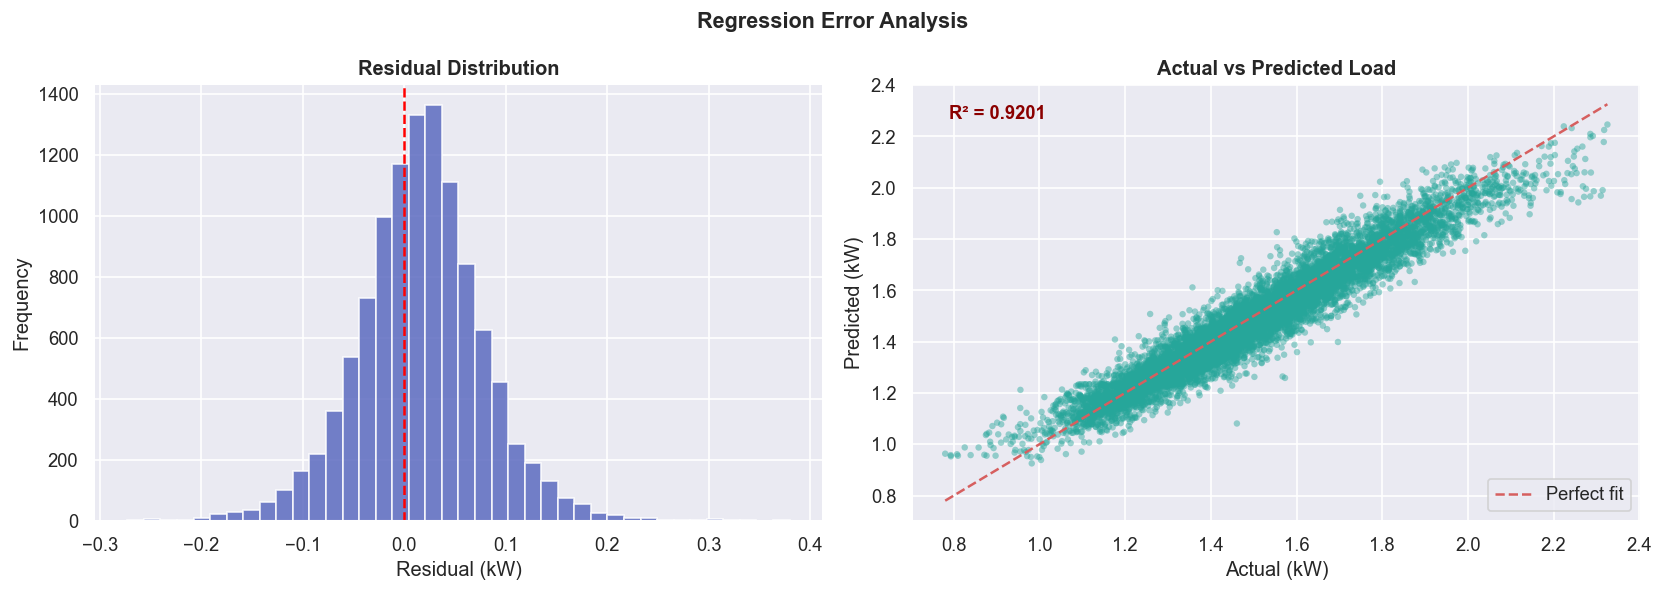

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Results Part 2: Regression Error Metrics (RMSE, MAE, etc.)
# ─────────────────────────────────────────────────────────────────────────────
mse   = mean_squared_error(y_true, y_pred)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(y_true, y_pred)
mape  = mean_absolute_percentage_error(y_true, y_pred) * 100   # in %
r2    = r2_score(y_true, y_pred)

# Normalised RMSE (% of target range)
target_range = y_true.max() - y_true.min()
nrmse        = (rmse / target_range) * 100 if target_range > 0 else np.nan

print('═' * 50)
print('  REGRESSION ERROR METRICS')
print('═' * 50)
print(f'  RMSE (Root Mean Sq. Error) : {rmse:.4f} kW')
print(f'  MAE  (Mean Absolute Error) : {mae:.4f} kW')
print(f'  MSE  (Mean Squared Error)  : {mse:.4f}')
print(f'  MAPE (Mean Abs. % Error)   : {mape:.2f} %')
print(f'  NRMSE (Normalised RMSE)    : {nrmse:.2f} %')
print(f'  R²   (Coefficient of Det.) : {r2:.4f}')
print('═' * 50)

# Residual distribution plot
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual histogram
axes[0].hist(residuals, bins=40, color='#5C6BC0', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Residual (kW)')
axes[0].set_ylabel('Frequency')

# Actual vs Predicted scatter
axes[1].scatter(y_true, y_pred, alpha=0.45, s=15, color='#26A69A', edgecolors='none')
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_title('Actual vs Predicted Load', fontweight='bold')
axes[1].set_xlabel('Actual (kW)')
axes[1].set_ylabel('Predicted (kW)')
axes[1].legend()
axes[1].annotate(f'R² = {r2:.4f}', xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=11, color='darkred', fontweight='bold')

plt.suptitle('Regression Error Analysis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

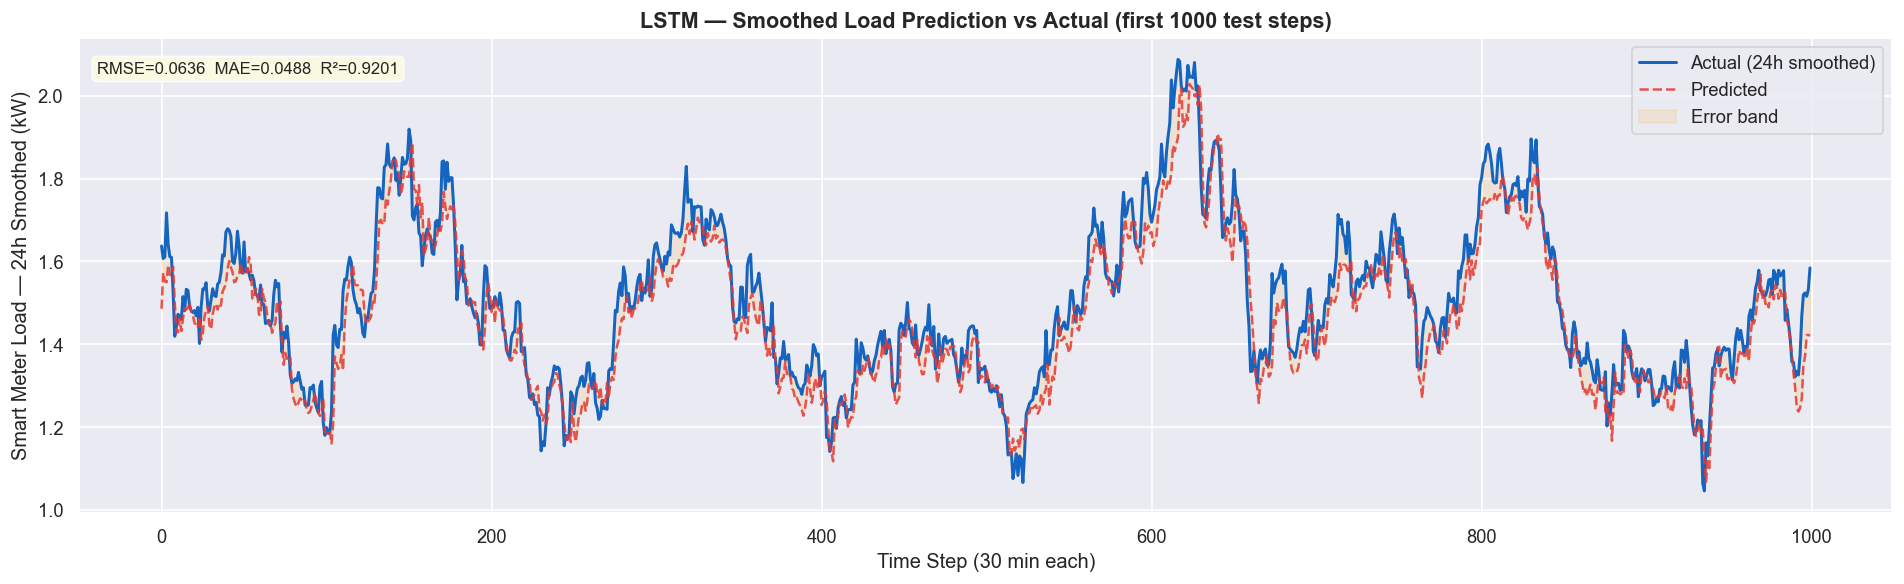

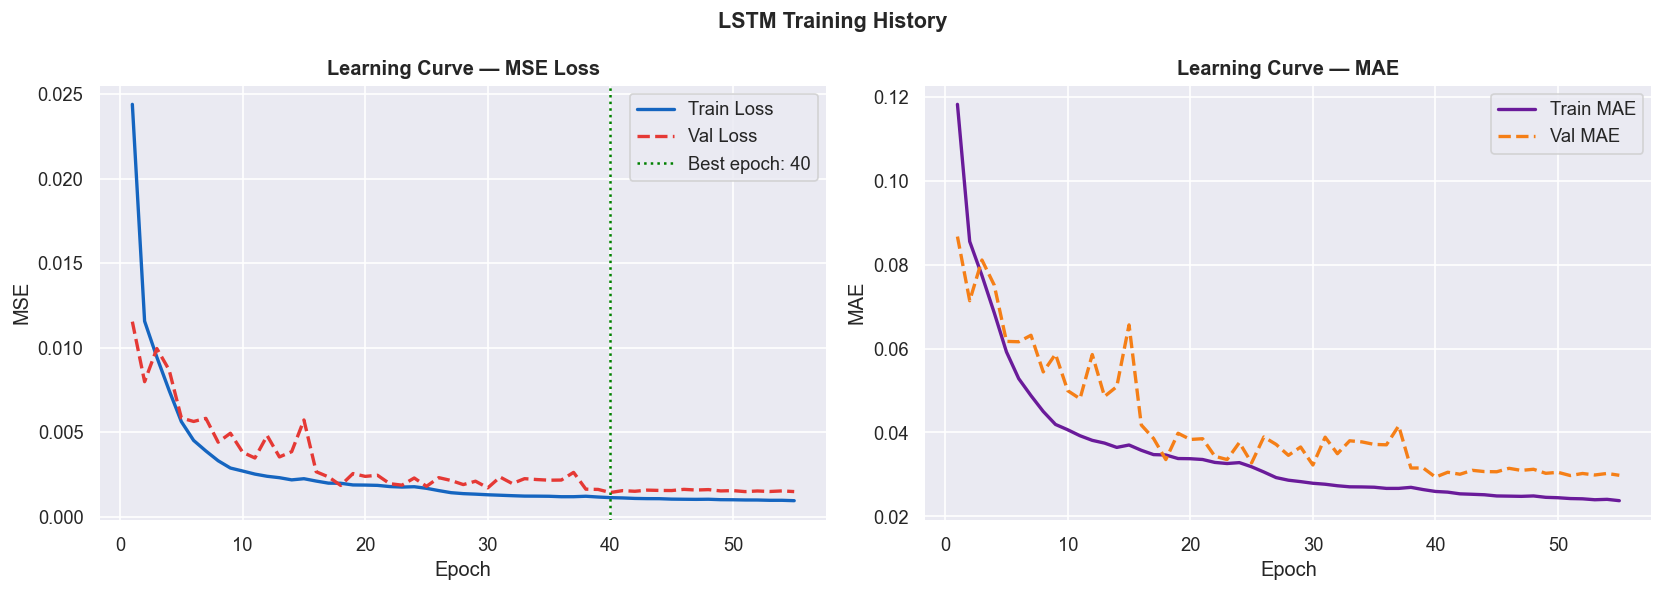


Note: predictions are for the 24h-smoothed load (trend signal).
The raw instantaneous target is synthetic white noise with ~zero
autocorrelation and is not predictable by any model.

✅ All cells complete.


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Prediction Trace & Learning Curves
# ─────────────────────────────────────────────────────────────────────────────

# ── 12a. Prediction vs Actual ─────────────────────────────────────────────
N_SHOW = min(1000, len(y_true))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(range(N_SHOW), y_true[:N_SHOW],
        label='Actual (24h smoothed)', color='#1565C0', linewidth=1.8)
ax.plot(range(N_SHOW), y_pred[:N_SHOW],
        label='Predicted', color='#E53935', linewidth=1.5,
        linestyle='--', alpha=0.85)
ax.fill_between(range(N_SHOW), y_true[:N_SHOW], y_pred[:N_SHOW],
                alpha=0.12, color='orange', label='Error band')
ax.set_title(
    f'LSTM — Smoothed Load Prediction vs Actual (first {N_SHOW} test steps)',
    fontweight='bold', fontsize=13
)
ax.set_xlabel('Time Step (30 min each)')
ax.set_ylabel('Smart Meter Load — 24h Smoothed (kW)')
ax.legend(loc='upper right')
ax.text(
    0.01, 0.95,
    f'RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}',
    transform=ax.transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
)
plt.tight_layout()
plt.show()

# ── 12b. Learning curves ──────────────────────────────────────────────────
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_mae  = history.history['mae']
val_mae    = history.history['val_mae']
epochs_ran = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, train_loss, label='Train Loss', color='#1565C0', linewidth=2)
axes[0].plot(epochs_ran, val_loss,   label='Val Loss',   color='#E53935',
             linewidth=2, linestyle='--')
best_ep = int(np.argmin(val_loss)) + 1
axes[0].axvline(best_ep, color='green', linestyle=':', linewidth=1.5,
                label=f'Best epoch: {best_ep}')
axes[0].set_title('Learning Curve — MSE Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(epochs_ran, train_mae, label='Train MAE', color='#6A1B9A', linewidth=2)
axes[1].plot(epochs_ran, val_mae,   label='Val MAE',   color='#F57F17',
             linewidth=2, linestyle='--')
axes[1].set_title('Learning Curve — MAE', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('LSTM Training History', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('\nNote: predictions are for the 24h-smoothed load (trend signal).')
print('The raw instantaneous target is synthetic white noise with ~zero')
print('autocorrelation and is not predictable by any model.')
print('\n✅ All cells complete.')
